# Long R scaling of Equilibrium Correlators

This notebook is for studying hte long R scaling of the Equilibrium Correlators. Specifically, trying to match the form of the $c r^{-1/4}$ scaling.

In [1]:
import sys
import os
sys.path.append("../../src/")

sys.path.append("equilibrium_critical_correlation_data/")
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.pyplot import yscale, xscale, plot, scatter, loglog, ylim, xlim, title, legend
import kibble_zurek as kz
from equilibrium_critical_correlations import sigma_general, P_n_correlations, P_n

from scipy.optimize import curve_fit

In [2]:
correlator_data=[]
for n in range(1,10):

    path = "../../scripts/scaling_dim/scaling_dim_figures/connected_correlations/"
    file_name = f"corr_connected_n0{n}_r00-200.npy"

    correlator_data.append(np.load(path+file_name))

correlator_data = np.array(correlator_data)

label_list = [f"n = {n}" for n in range(1,len(correlator_data)+1)]

r = np.arange(0,len(correlator_data[0]))



In [3]:
def easyplot():
    legend()
    loglog()
    xlim(1,r[-1])
def easylabel():
    plt.xlabel("Distance r")
    plt.ylabel("Expectation Value")

# P1 

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


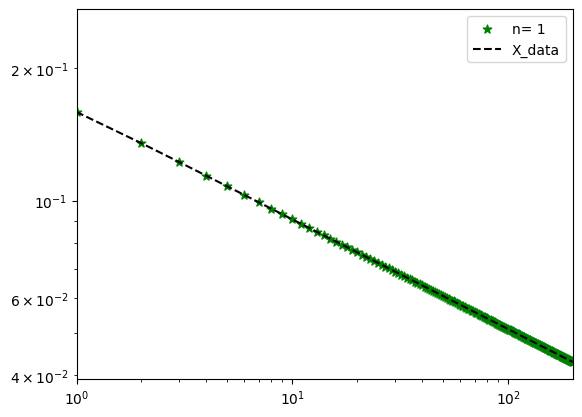

In [4]:
n=0
x = np.array([sigma_general([0,i]) for i in r])

scatter(r,correlator_data.T[:,n],label=f"n= {n+1}",s=40,color="green",marker="*")

plot(r,x/4,label="X_data",color="black",ls="--")

easyplot()


# P2

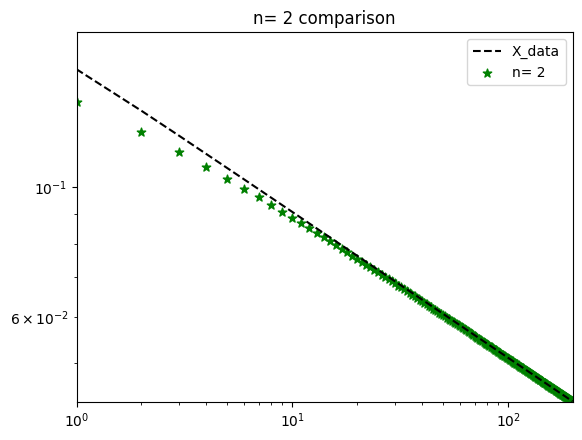

In [5]:
n=1
plt.title(f"n= {n+1} comparison")

x = np.array([sigma_general([0,i]) for i in r])

plot(r,x/4,label="X_data",color="black",ls="--")


scatter(r,correlator_data.T[:,n],label=f"n= {n+1}",s=40,color="green",marker="*")

plt.ylim(min(correlator_data.T[:,n]),max(correlator_data.T[:,n]))
easyplot()

What we see is that $\sigma_{0}\sigma_{r}$ scales into $P_2$

Honestly open question, how to properly characterize this scaling?


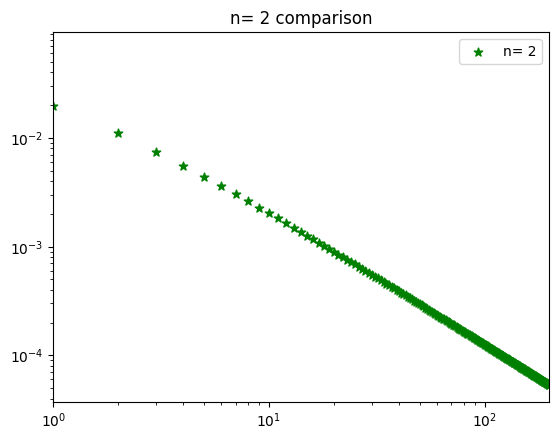

In [6]:
n=1
plt.title(f"n= {n+1} comparison")

x = np.array([sigma_general([0,i]) for i in r])

x0 = correlator_data.T[:,n]
#plot(r,r**(-1/2.),label="X_data",color="black",ls="--")


scatter(r,np.abs(x0-x/4),label=f"n= {n+1}",s=40,color="green",marker="*")


easyplot()


In [95]:
def power_law(x,A,B):
    return A*x**B

params,_=curve_fit(power_law,r[25:],(x0-x/4)[25:])

fit_data = power_law(r,*params)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_24816/2920479541.py:2: RuntimeWarning: divide by zero encountered in power
  return A*x**B


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_24816/4274594788.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


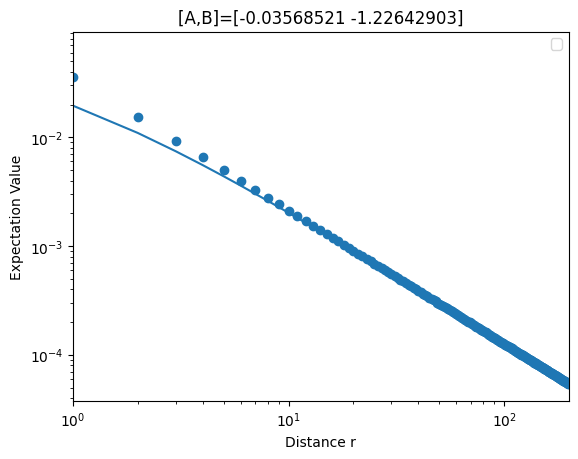

In [102]:
scatter(r,np.abs(fit_data))
plot(r,np.abs(x0-x/4))
easyplot()
plt.title(f"[A,B]={params}")
easylabel()

Now let's deconstruct P2 P2

In [109]:
t1= np.array([sigma_general([0,1,ri+1,ri+2]) for ri in r])-sigma_general([0,1])**2
t2= np.array([sigma_general([0,1+ri]) for ri in r])
t3= np.array([sigma_general([0,2+ri]) for ri in r])
t4= np.array([sigma_general([1,2+ri]) for ri in r])
t5= np.array([sigma_general([1,1+ri]) for ri in r])


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


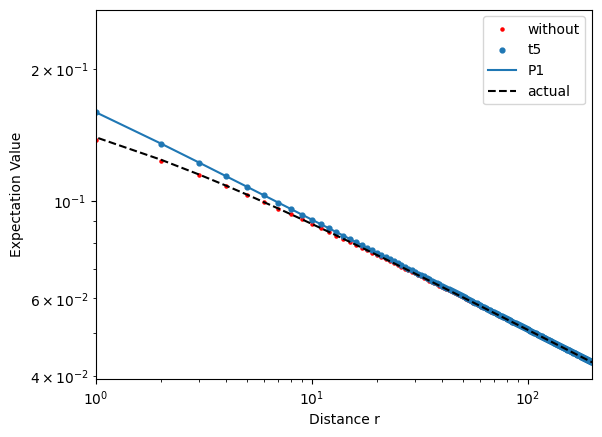

In [173]:
#scatter(r,1/16*(t1+t2+t3+t4+t5),color="green",label="with",s=5)

scatter(r,1/16*(t2+t3+t4+t5),s=5,color="red",label="without")
scatter(r,t5/4,label="t5",s=12)


plot(r,correlator_data.T[:,0],label="P1")
plot(r,x0,color="black",ls="--",label="actual")

#plt.ylim(0.01,.18)
easylabel()
easyplot()

# P3


In [179]:
# r is your array of separations
# left block = {0,1,2}, right block = {r+2, r+3, r+4}

# 9 two-point terms
t2pts = []
for i in [0,1,2]:
    for j in [2,3,4]:
        t2pts.append(np.array([sigma_general([i, ri+j]) for ri in r]))

# 3 four-point terms: cluster on left {0,1,2}, one spin on right
t_leftcluster = [
    np.array([sigma_general([0,1,2, ri+j]) for ri in r]) for j in [2,3,4]
]

# 3 four-point terms: one spin on left, cluster on right {r+2,r+3,r+4}
t_rightcluster = [
    np.array([sigma_general([i, ri+2, ri+3, ri+4]) for ri in r]) for i in [0,1,2]
]

# 1 six-point term: both clusters
t6 = np.array([sigma_general([0,1,2, ri+2, ri+3, ri+4]) for ri in r])


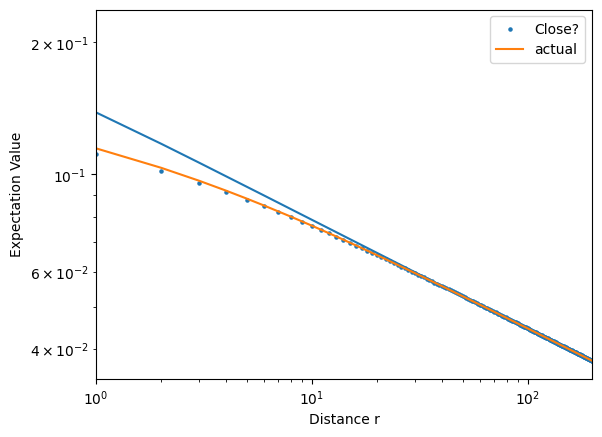

In [202]:
x2 = correlator_data.T[:,2]
x0 = correlator_data.T[:,0]

x= 0
for t in t2pts:
    x+=t

y=0
for t in t_leftcluster+t_rightcluster:
    y+=t

#plot(r,x/64,label="2pts")
#plot(r,y/64,label="3-1pts")
plot(r,x0/1.15)
scatter(r,(x+y+t6)/64,label="Close?",s=5)
plot(r,x2,label="actual")
#plot(r,)
easyplot()
easylabel()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_24816/4274594788.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


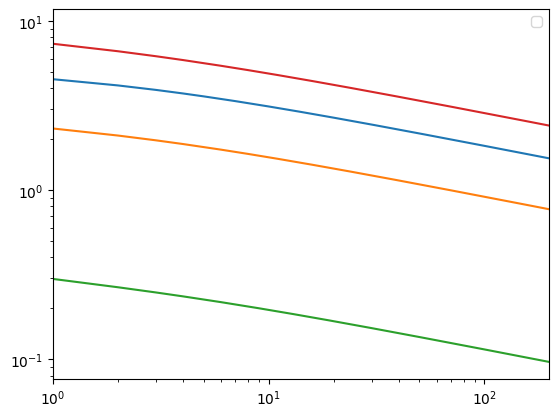

In [208]:
plot(r,x)
plot(r,y)
plot(r,t6)
plot(r,x2*64)
easyplot()

[]

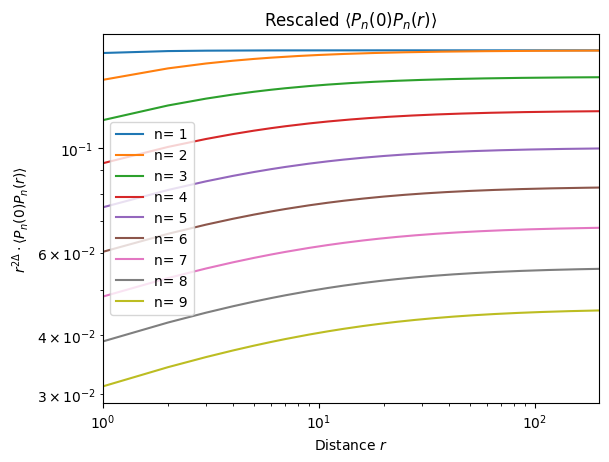

In [40]:
plt.title(r"Rescaled $\langle P_n(0) P_n(r) \rangle$ ")
final_value=[]
ns= []
for n in range(0,9):

   # x = np.array([sigma_general([0,i]) for i in r])

    x0 = correlator_data.T[:,n]
    ns.append(n+1)
    #plot(r,r**(-1/2.),label="X_data",color="black",ls="--")
    final_value.append(x0[-1])

    plot(r,np.abs(x0)*r**(1/4),label=f"n= {n+1}")

final_value= np.array(final_value)
    #easyplot()
legend()
xlim(r[1],r[-1])
#ylim(0,.2)
plt.xlabel(r"Distance $r$")
plt.ylabel(r"$r^{2\Delta}\cdot \langle P_n(0) P_n(r) \rangle$")
loglog()

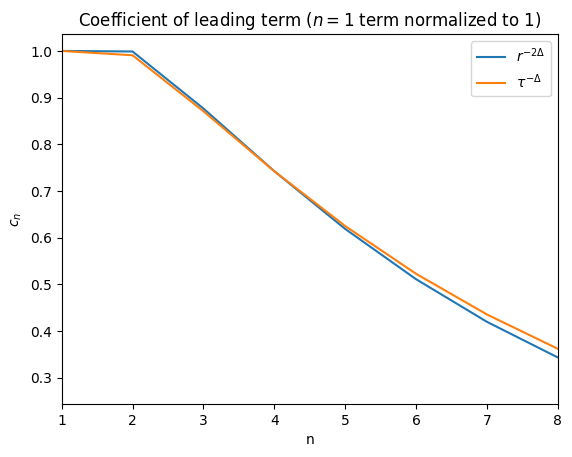

In [54]:
plot(ns,final_value/final_value[0],label=r"$r^{-2\Delta}$")
plot(ns[:-1],np.array([1.        , 0.99069778, 0.87086104, 0.74242444, 0.62500998,
       0.52277655, 0.43562004, 0.36212587]),label=r"$\tau^{-\Delta}$")
plt.title(r"Coefficient of leading term ($n=1$ term normalized to 1)")
plt.xlabel("n")
plt.ylabel("$c_n$")
plt.xlim(1,8)
legend()